In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys 
sys.path.append('../src')

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader
from datas import SequenceBigWigDataset
from tqdm import tqdm

In [3]:
fasta_path = '../data/GRCm38.primary_assembly.genome.fa'
bed_path = '../data/bed_files/SOX2_clusters_sorted.bed'

timepoints = {
    'DMSO': '../data/bws_for_predictor/SPT16_4D_DMSO_Sox2_S40_1_120_sorted.bw',
    '2H': '../data/bws_for_predictor/SPT16_4D_2HdTAG_Sox2_S46_1_120_sorted.bw',
    '6H': '../data/bws_for_predictor/SPT16_4D_6HdTAG_Sox2_S49_1_120_sorted.bw',
    '30m': '../data/bws_for_predictor/SPT16_D4_30dTAG_Sox2_S7_1_120_sorted.bw',
    '10d': '../data/bws_for_predictor/SPT16_4D_10dTAG_Sox2_rep2_S58_1_120_sorted.bw'
}

clusters = ['cluster_1', 'cluster_2', 'cluster_3', 'cluster_4']

window_left = 1000
window_right = 1000
batch_size = 512

In [4]:
all_stats = {} # (cluster, tp) -> (mean, std, count)

for cluster in clusters:
    print(f"Processing {cluster}...")
    for tp_name, bw_path in timepoints.items():
        # Initialize dataset for this specific cluster and timepoint
        ds = SequenceBigWigDataset(
            fasta_path=fasta_path,
            bigwig_path=bw_path,
            bed_path=bed_path,
            window_left=window_left,
            window_right=window_right,
            subset_dict={'deepTools_group': cluster}
        )
        
        if len(ds) == 0:
            print(f"  Skipping {tp_name}: No intervals found.")
            continue
            
        loader = DataLoader(ds, batch_size=batch_size, num_workers=4, shuffle=False)
        
        # Collect signal
        tp_counts = []
        for _, y_batch in loader:
            tp_counts.append(y_batch.numpy())
        
        tp_counts = np.vstack(tp_counts)
        
        # Calculate stats immediately to save memory
        mean_val = np.mean(tp_counts, axis=0)
        std_val = np.std(tp_counts, axis=0)
        all_stats[(cluster, tp_name)] = (mean_val, std_val, len(tp_counts))
        
        print(f"  {tp_name}: {len(tp_counts)} regions")

Processing cluster_1...
  DMSO: 519 regions
  2H: 517 regions
  6H: 521 regions
  30m: 507 regions
  10d: 518 regions
Processing cluster_2...
  DMSO: 501 regions
  2H: 504 regions
  6H: 503 regions
  30m: 501 regions
  10d: 502 regions
Processing cluster_3...
  DMSO: 4832 regions
  2H: 4864 regions
  6H: 4893 regions
  30m: 4771 regions
  10d: 4831 regions
Processing cluster_4...
  DMSO: 13879 regions
  2H: 12408 regions
  6H: 13456 regions
  30m: 10841 regions
  10d: 13648 regions


In [ ]:
tp_names = 

['DMSO', '2H', '6H', '30m', '10d']

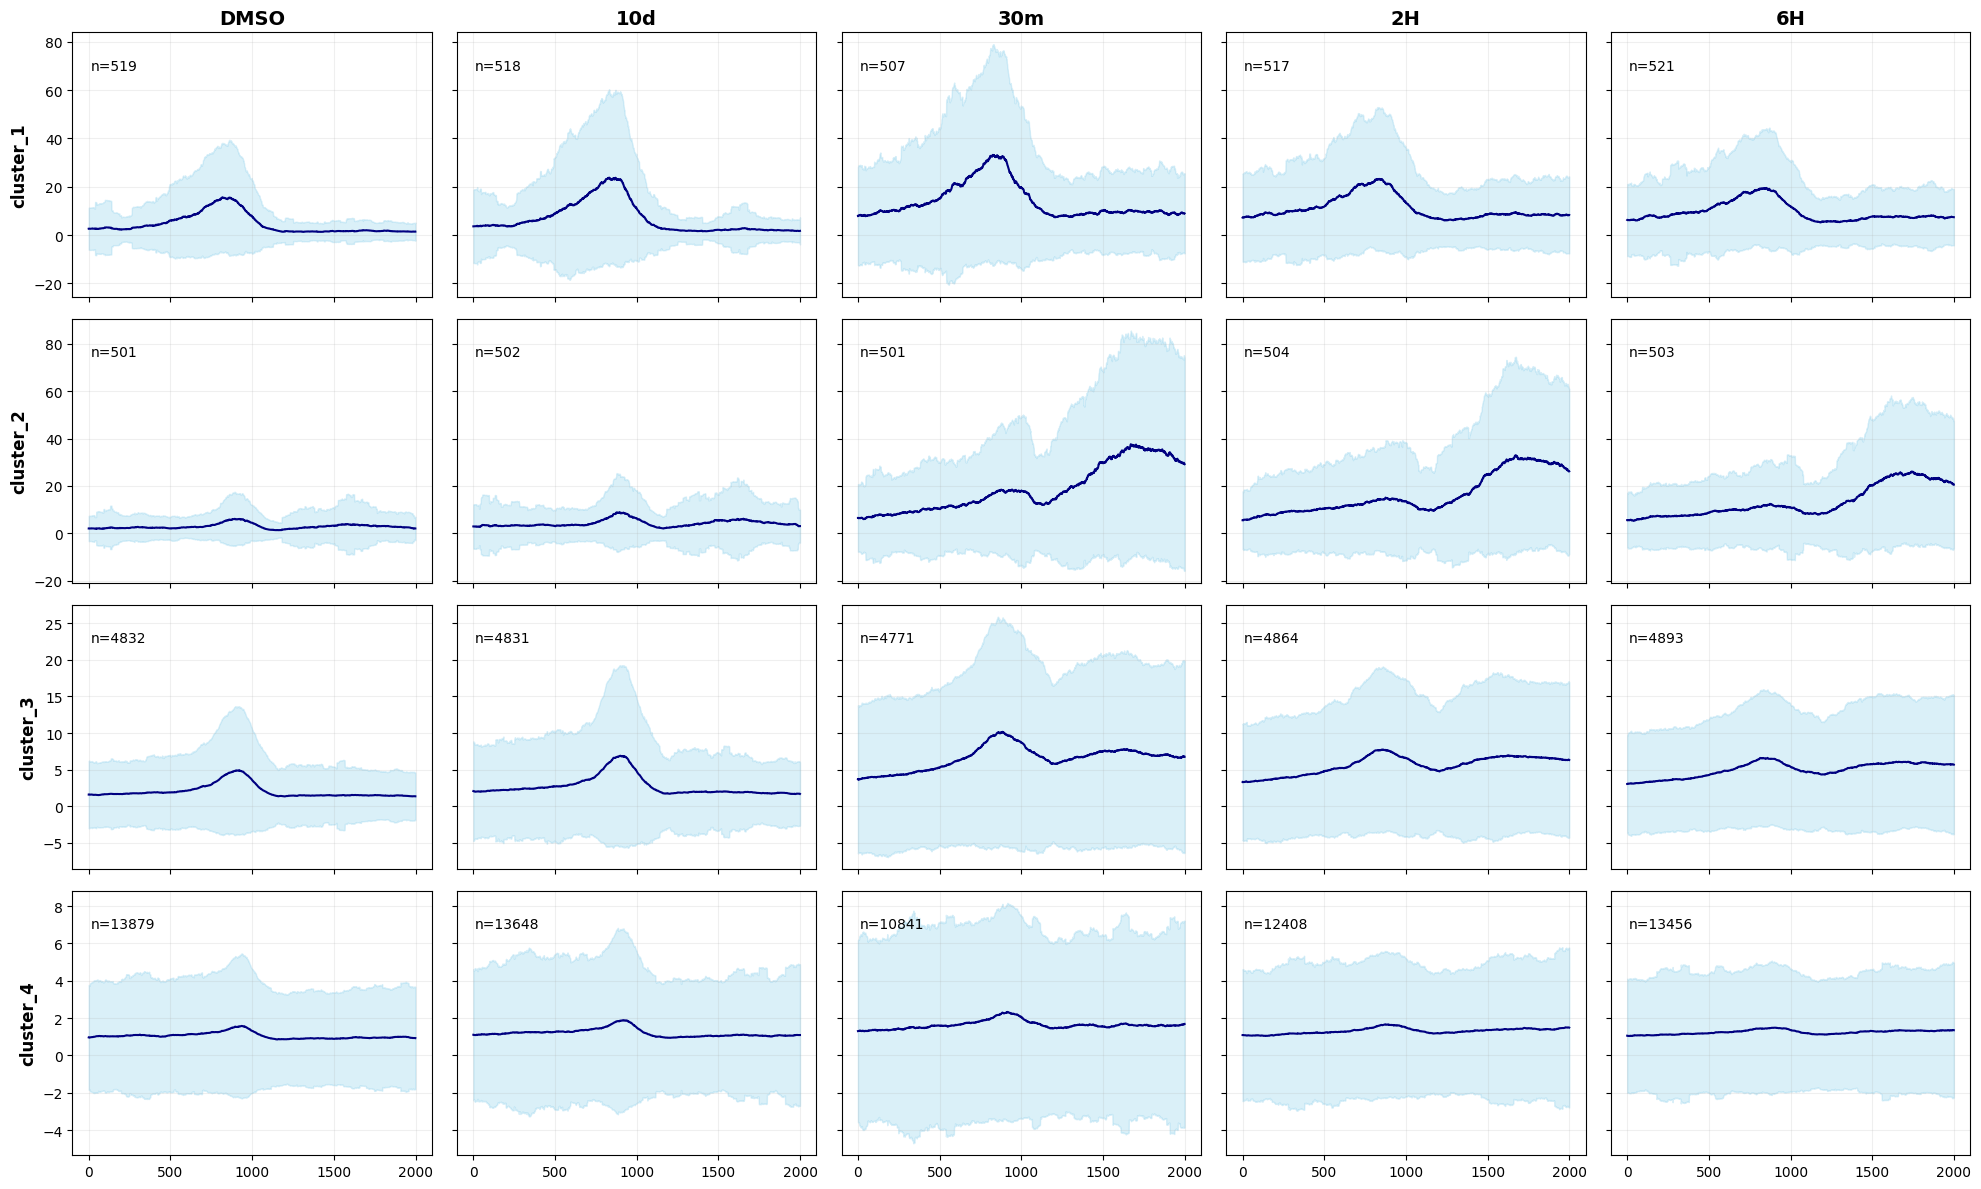

In [8]:
n_rows = len(clusters)
n_cols = len(timepoints)
# tp_names = list(timepoints.keys())
tp_names = ['DMSO', '10d', '30m', '2H', '6H']

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, sharey='row')

for r, cluster in enumerate(clusters):
    for c, tp_name in enumerate(tp_names):
        ax = axes[r, c]
        
        if (cluster, tp_name) in all_stats:
            mean_line, std_line, count = all_stats[(cluster, tp_name)]
            x = np.arange(len(mean_line))
            
            ax.fill_between(x, mean_line - std_line, mean_line + std_line, color='skyblue', alpha=0.3)
            ax.plot(x, mean_line, color='navy', lw=1.5)
            
            if r == 0:
                ax.set_title(f"{tp_name}", fontsize=14, fontweight='bold')
            if c == 0:
                ax.set_ylabel(f"{cluster}", fontsize=12, fontweight='bold')
            
            # Add count annotation
            ax.text(0.05, 0.9, f"n={count}", transform=ax.transAxes, fontsize=10, verticalalignment='top')
        else:
            ax.text(0.5, 0.5, "No Data", ha='center', va='center')
            
        ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../results/cluster_timepoint_windows.png', dpi=300)
plt.show()